In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('03_Data_cleaned_after_pandas.csv')
print(df.shape)

(1470, 32)


In [20]:
df['RiskScore'] = (
    (df['OverTime'] == 'Yes').astype(int) * 2 +   # Weight = 2 (most important)
    (df['WorkLifeBalance'] == 1).astype(int) * 2 +  # Weight = 2 (equally strong)
    (df['JobSatisfaction'] == 1).astype(int) +
    (df['EnvironmentSatisfaction'] == 1).astype(int) +
    (df['JobLevel'] == 1).astype(int) +
    (df['StockOptionLevel'] == 0).astype(int) +
    (df['MaritalStatus'] == 'Single').astype(int) +
    (df['BusinessTravel'] == 'Travel_Frequently').astype(int) +
    (df['MonthlyIncome'] < 3000).astype(int) +
    (df['YearsAtCompany'] <= 2).astype(int) +
    (df['Age'] < 30).astype(int) +
    (df['NumCompaniesWorked'] >= 4).astype(int) +
    (df['DistanceFromHome'] > 15).astype(int) +
    (df['JobRole'].isin(['Sales Representative', 'Laboratory Technician',
                          'Human Resources'])).astype(int) +
    (df['Department'].isin(['Sales', 'Human Resources'])).astype(int) +
    ((df['Age'] < 30) & (df['MaritalStatus'] == 'Single')).astype(int)
)

print("RiskScore distribution:")
print(df['RiskScore'].describe())
print("\nValue counts:")
print(df['RiskScore'].value_counts().sort_index())

RiskScore distribution:
count    1470.000000
mean        4.325850
std         2.426442
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        13.000000
Name: RiskScore, dtype: float64

Value counts:
RiskScore
0      38
1     119
2     208
3     240
4     243
5     183
6     167
7     119
8      73
9      39
10     18
11     11
12     10
13      2
Name: count, dtype: int64


In [21]:
df['RiskCategory'] = pd.cut(
    df['RiskScore'],
    bins=[-1, 2, 5, 8, 18],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
)

print("\nRisk Category distribution:")
print(df['RiskCategory'].value_counts())

print("\nAttrition rate by Risk Category:")
df['Attrition_Binary'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df.groupby('RiskCategory')['Attrition_Binary'].mean() * 100)


Risk Category distribution:
RiskCategory
Moderate Risk    666
Low Risk         365
High Risk        359
Critical Risk     80
Name: count, dtype: int64

Attrition rate by Risk Category:
RiskCategory
Low Risk          3.561644
Moderate Risk     6.906907
High Risk        32.311978
Critical Risk    77.500000
Name: Attrition_Binary, dtype: float64


C:\Users\YASH\AppData\Local\Temp\ipykernel_20924\2085345421.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('RiskCategory')['Attrition_Binary'].mean() * 100)


C:\Users\YASH\AppData\Local\Temp\ipykernel_20924\530769015.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_attr = df.groupby('RiskCategory')['Attrition_Binary'].mean() * 100


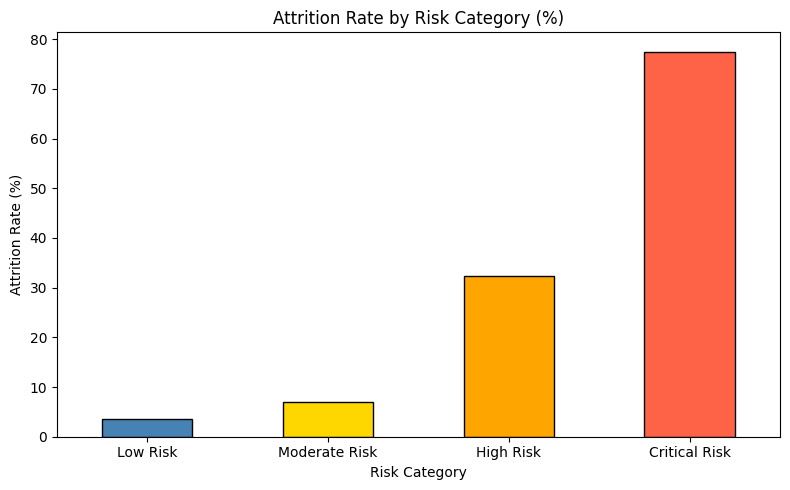

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
risk_attr = df.groupby('RiskCategory')['Attrition_Binary'].mean() * 100
risk_attr.plot(kind='bar', color=['steelblue', 'gold', 'orange', 'tomato'],
               edgecolor='black')
plt.title('Attrition Rate by Risk Category (%)')
plt.xlabel('Risk Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('risk_category_validation.png')
plt.show()

In [23]:
df['IncomeBracket'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 7000, 15000, 100000],
    labels=['Low (<3K)', 'Medium (3K-7K)', 'High (7K-15K)', 'Very High (15K+)']
)
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60']
)
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 40],
    labels=['New (0-2 yrs)', 'Early (3-5 yrs)',
            'Mid (6-10 yrs)', 'Senior (10+ yrs)']
)
df['SatisfactionIndex'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction']
) / 3
df['BurnoutFlag'] = (
    (df['OverTime'] == 'Yes') &
    (df['WorkLifeBalance'] <= 2)
).astype(int)

print("BurnoutFlag distribution:")
print(df['BurnoutFlag'].value_counts())
print(f"\nAttrition rate with Burnout: "
      f"{df[df['BurnoutFlag']==1]['Attrition_Binary'].mean()*100:.1f}%")
print(f"Attrition rate without Burnout: "
      f"{df[df['BurnoutFlag']==0]['Attrition_Binary'].mean()*100:.1f}%")

BurnoutFlag distribution:
BurnoutFlag
0    1344
1     126
Name: count, dtype: int64

Attrition rate with Burnout: 33.3%
Attrition rate without Burnout: 14.5%


In [24]:
new_features = ['RiskScore','RiskCategory', 'IncomeBracket',
                'AgeGroup', 'TenureGroup', 'SatisfactionIndex', 'BurnoutFlag']

print("All new features created:")
print(df[new_features].head(10))
print("\nData types:")
print(df[new_features].dtypes)

All new features created:
   RiskScore   RiskCategory   IncomeBracket AgeGroup     TenureGroup  \
0          8      High Risk  Medium (3K-7K)    36-45  Mid (6-10 yrs)   
1          1       Low Risk  Medium (3K-7K)    46-60  Mid (6-10 yrs)   
2          9  Critical Risk       Low (<3K)    36-45   New (0-2 yrs)   
3          6      High Risk       Low (<3K)    26-35  Mid (6-10 yrs)   
4          6      High Risk  Medium (3K-7K)    26-35   New (0-2 yrs)   
5          5  Moderate Risk  Medium (3K-7K)    26-35  Mid (6-10 yrs)   
6          8      High Risk       Low (<3K)    46-60   New (0-2 yrs)   
7          5  Moderate Risk       Low (<3K)    26-35   New (0-2 yrs)   
8          4  Moderate Risk   High (7K-15K)    36-45  Mid (6-10 yrs)   
9          2       Low Risk  Medium (3K-7K)    36-45  Mid (6-10 yrs)   

   SatisfactionIndex  BurnoutFlag  
0           2.333333            1  
1           3.000000            0  
2           3.000000            0  
3           3.333333            0  
4

In [25]:
df.to_csv('04_Data_cleaned_after_FE.csv', index=False)
print(f"Final dataset saved: {df.shape}")
print(f"New columns added: {new_features}")

Final dataset saved: (1470, 39)
New columns added: ['RiskScore', 'RiskCategory', 'IncomeBracket', 'AgeGroup', 'TenureGroup', 'SatisfactionIndex', 'BurnoutFlag']
